# Final Project: Predicting 30-Day Readmission for Diabetic Patients

This notebook builds a complete **scikit-learn machine learning pipeline** for the **Diabetes 130-US hospitals (1999–2008)** dataset.

## Project goal
Predict whether a diabetic patient will be **readmitted within 30 days** after discharge.

## Target definition
We convert the original `readmitted` variable into a binary target:

- `1` = `<30`
- `0` = `>30` or `NO`

## Models compared
This notebook trains and compares five models:

1. Logistic Regression  
2. K-Nearest Neighbors  
3. Decision Tree  
4. Random Forest  
5. Gradient Boosting  

## Evaluation
Primary metric: **AUC**  
Secondary metrics: Accuracy, Precision, Recall, F1-score

In [1]:
# If needed, uncomment and run:
# !pip install pandas numpy matplotlib scikit-learn imbalanced-learn seaborn

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

RANDOM_STATE = 42

## 1. Load data

Place these files in the same folder as this notebook:

- `diabetic_data.csv`
- `IDs_mapping.csv` or `IDs_mappings.csv` (optional)
- `Data Dictionary.png` (optional)

This notebook uses `diabetic_data.csv` directly.

In [3]:
# Adjust this path if needed
DATA_DIR = Path("./data")

# Main data file
data_path = DATA_DIR / "diabetic_data.csv"

if not data_path.exists():
    raise FileNotFoundError(
        "Could not find 'diabetic_data.csv'. Put the file in the same folder as this notebook, "
        "or update DATA_DIR above."
    )

df_raw = pd.read_csv(data_path)
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 2. Initial inspection

In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [5]:
df_raw.describe(include="all").T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,NaN,NaN,NaN,165201645.622978,102640295.983457,12522.0,84961194.0,152388987.0,230270887.5,443867222.0
patient_nbr,101766.0,NaN,NaN,NaN,54330400.694947,38696359.346534,135.0,23413221.0,45505143.0,87545949.75,189502619.0
race,101766,6,Caucasian,76099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,101766,3,Female,54708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,101766,10,[70-80),26068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,101766,10,?,98569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,101766.0,NaN,NaN,NaN,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,NaN,NaN,NaN,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,NaN,NaN,NaN,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,NaN,NaN,NaN,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0


In [6]:
# Show raw target distribution
df_raw["readmitted"].value_counts(dropna=False)

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

## 3. Data cleaning and target construction

In [7]:
def clean_diabetes_data(df: pd.DataFrame, missing_col_threshold: float = 0.80) -> pd.DataFrame:
    df = df.copy()

    # Convert placeholder missing values to actual NaN
    df = df.replace("?", np.nan)

    # Remove ID-like variables
    for col in ["encounter_id", "patient_nbr"]:
        if col in df.columns:
            df = df.drop(columns=col)

    # Remove rows with missing target
    df = df[df["readmitted"].notna()].copy()

    # Binary target: <30 = 1, otherwise = 0
    df["target_readmit_30d"] = (df["readmitted"] == "<30").astype(int)

    # Drop original target after creating the binary version
    df = df.drop(columns=["readmitted"])

    # Drop columns that are entirely missing
    all_missing_cols = df.columns[df.isna().all()].tolist()
    if all_missing_cols:
        print("Dropping all-missing columns:", all_missing_cols)
        df = df.drop(columns=all_missing_cols)

    # Drop columns with more than the specified missing-value threshold
    missing_rate = df.isna().mean()
    high_missing_cols = missing_rate[missing_rate > missing_col_threshold].index.tolist()
    if high_missing_cols:
        print(
            f"Dropping columns with more than {int(missing_col_threshold * 100)}% missing values:",
            high_missing_cols
        )
        df = df.drop(columns=high_missing_cols)

    return df

In [8]:
df = clean_diabetes_data(df_raw)
print("Cleaned shape:", df.shape)
df.head()
df["target_readmit_30d"].value_counts(normalize=True)

Dropping columns with more than 80% missing values: ['weight', 'max_glu_serum', 'A1Cresult']
Cleaned shape: (101766, 45)


target_readmit_30d
0    0.888401
1    0.111599
Name: proportion, dtype: float64

## 4. Optional feature engineering

This dataset contains many medication columns with values like `No`, `Steady`, `Up`, `Down`.

We add a few clinically meaningful summary features:

- `num_diabetes_drugs_used`
- `num_diabetes_drugs_changed`
- `service_use_total`
- `has_prior_inpatient`
- `has_emergency_visit`
- `long_stay`

In [9]:
MEDICATION_COLS = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "examide", "citoglipton", "insulin", "glyburide-metformin",
    "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone",
    "metformin-pioglitazone"
]

def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    meds_present = [c for c in MEDICATION_COLS if c in df.columns]
    if meds_present:
        med_frame = df[meds_present].fillna("No")
        df["num_diabetes_drugs_used"] = (med_frame != "No").sum(axis=1)
        df["num_diabetes_drugs_changed"] = med_frame.isin(["Up", "Down"]).sum(axis=1)

    if {"number_outpatient", "number_emergency", "number_inpatient"}.issubset(df.columns):
        df["service_use_total"] = (
            df["number_outpatient"].fillna(0)
            + df["number_emergency"].fillna(0)
            + df["number_inpatient"].fillna(0)
        )
        df["has_prior_inpatient"] = (df["number_inpatient"].fillna(0) > 0).astype(int)
        df["has_emergency_visit"] = (df["number_emergency"].fillna(0) > 0).astype(int)

    if "time_in_hospital" in df.columns:
        df["long_stay"] = (df["time_in_hospital"].fillna(0) >= 7).astype(int)

    return df

df = add_engineered_features(df)
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,...,metformin-pioglitazone,change,diabetesMed,target_readmit_30d,num_diabetes_drugs_used,num_diabetes_drugs_changed,service_use_total,has_prior_inpatient,has_emergency_visit,long_stay
0,Caucasian,Female,[0-10),6,25,1,1,NaN,Pediatrics-Endocrinology,41,...,No,No,No,0,0,0,0,0,0,0
1,Caucasian,Female,[10-20),1,1,7,3,NaN,NaN,59,...,No,Ch,Yes,0,1,1,0,0,0,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,NaN,11,...,No,No,Yes,0,1,0,3,1,0,0
3,Caucasian,Male,[30-40),1,1,7,2,NaN,NaN,44,...,No,Ch,Yes,0,1,1,0,0,0,0
4,Caucasian,Male,[40-50),1,1,7,1,NaN,NaN,51,...,No,Ch,Yes,0,2,0,0,0,0,0


## 5. Quick EDA

In [10]:
print("Rows, columns:", df.shape)
print("\nMissing values (top 20):")
display(df.isna().sum().sort_values(ascending=False).head(20))

Rows, columns: (101766, 51)

Missing values (top 20):


medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
gender                          0
age                             0
time_in_hospital                0
admission_type_id               0
discharge_disposition_id        0
num_procedures                  0
num_lab_procedures              0
admission_source_id             0
num_medications                 0
number_inpatient                0
number_emergency                0
number_outpatient               0
number_diagnoses                0
metformin                       0
dtype: int64

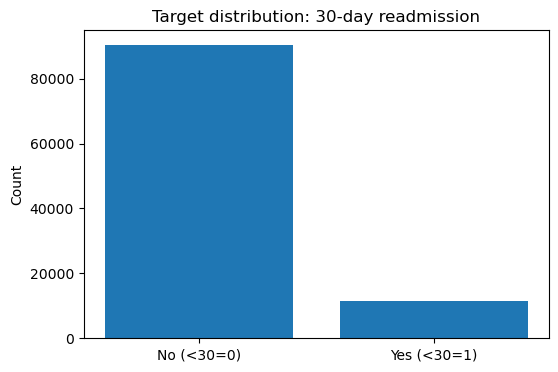

In [11]:
# Target balance
target_counts = df["target_readmit_30d"].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(["No (<30=0)", "Yes (<30=1)"], [target_counts.get(0,0), target_counts.get(1,0)])
plt.title("Target distribution: 30-day readmission")
plt.ylabel("Count")
plt.show()

In [12]:
numeric_preview = [
    c for c in [
        "time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
        "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses",
        "service_use_total", "num_diabetes_drugs_used"
    ] if c in df.columns
]

df[numeric_preview].describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.422607,1.933600,1.0,6.0,8.0,9.0,16.0
service_use_total,101766.0,1.202759,2.291781,0.0,0.0,0.0,2.0,80.0
num_diabetes_drugs_used,101766.0,1.179706,0.920190,0.0,1.0,1.0,2.0,6.0


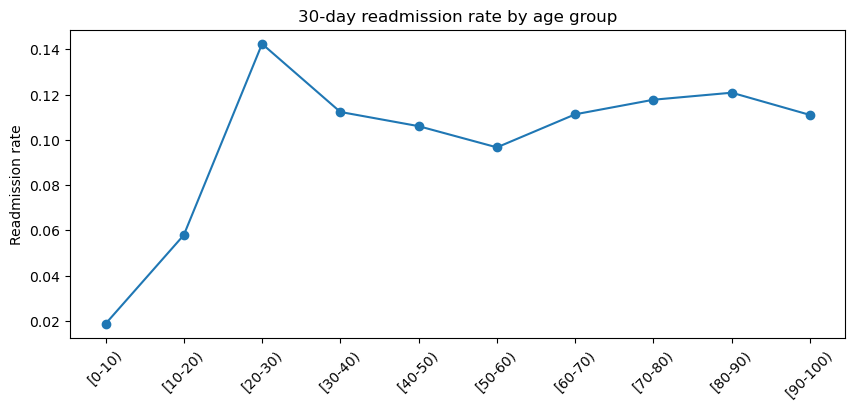

In [13]:
# Readmission rate by age
if "age" in df.columns:
    age_rate = df.groupby("age")["target_readmit_30d"].mean().sort_index()
    plt.figure(figsize=(10,4))
    plt.plot(age_rate.index, age_rate.values, marker="o")
    plt.xticks(rotation=45)
    plt.title("30-day readmission rate by age group")
    plt.ylabel("Readmission rate")
    plt.show()

In [14]:
# Readmission rate by A1Cresult
if "A1Cresult" in df.columns:
    a1c_rate = df.groupby("A1Cresult")["target_readmit_30d"].mean().sort_values(ascending=False)
    plt.figure(figsize=(6,4))
    plt.bar(a1c_rate.index.astype(str), a1c_rate.values)
    plt.title("30-day readmission rate by A1C result")
    plt.ylabel("Readmission rate")
    plt.show()

## 6. Train/validation split

In [15]:
X = df.drop(columns=["target_readmit_30d"])
y = df["target_readmit_30d"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train positive rate:", y_train.mean().round(4))
print("Test positive rate :", y_test.mean().round(4))

Train shape: (81412, 50)
Test shape : (20354, 50)
Train positive rate: 0.1116
Test positive rate : 0.1116


## 7. Build preprocessing + balancing pipeline

We use:
- median imputation for numeric columns
- most-frequent imputation + one-hot encoding for categorical columns
- `RandomOverSampler` from **imblearn**, applied **only inside the training folds / training split**

This avoids data leakage and addresses class imbalance in a pipeline-safe way.

To keep all models compatible, the encoder outputs a dense matrix.

In [16]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Example categorical columns:", categorical_features[:10])

Numeric features: 17
Categorical features: 33
Example categorical columns: ['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide']


In [17]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

sampler = RandomOverSampler(random_state=RANDOM_STATE)

## 8. Define models

Chosen models:
1. Logistic Regression  
2. KNN  
3. Decision Tree  
4. Random Forest  
5. Gradient Boosting

All models will use the same preprocessing + **imblearn balancing step** inside a single pipeline.

In [18]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=25
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "MLP (Neural Net)": MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=200,
    random_state=RANDOM_STATE
),
}

pipelines = {
    name: ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", sampler),
        ("model", model)
    ])
    for name, model in models.items()
}

list(pipelines.keys())

['Logistic Regression',
 'KNN',
 'Decision Tree',
 'Random Forest',
 'Gradient Boosting',
 'MLP (Neural Net)']

## 9. Cross-validation comparison

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "auc": "roc_auc",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_rows = []

for name, pipe in pipelines.items():
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    cv_rows.append({
        "model": name,
        "cv_auc_mean": scores["test_auc"].mean(),
        "cv_auc_std": scores["test_auc"].std(),
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_precision_mean": scores["test_precision"].mean(),
        "cv_recall_mean": scores["test_recall"].mean(),
        "cv_f1_mean": scores["test_f1"].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("cv_auc_mean", ascending=False)
cv_results

,model,cv_auc_mean,cv_auc_std,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean
4,Gradient Boosting,0.668752,0.006665,0.638469,0.174719,0.601363,0.270757
3,Random Forest,0.651401,0.006399,0.888370,0.501440,0.017500,0.033797
0,Logistic Regression,0.628127,0.005233,0.639328,0.161387,0.531697,0.247609
1,KNN,0.583241,0.005815,0.578011,0.138595,0.533238,0.220003
5,MLP (Neural Net),0.569497,0.009904,0.804980,0.156229,0.169383,0.162497
2,Decision Tree,0.541954,0.002505,0.792721,0.169123,0.219128,0.190894


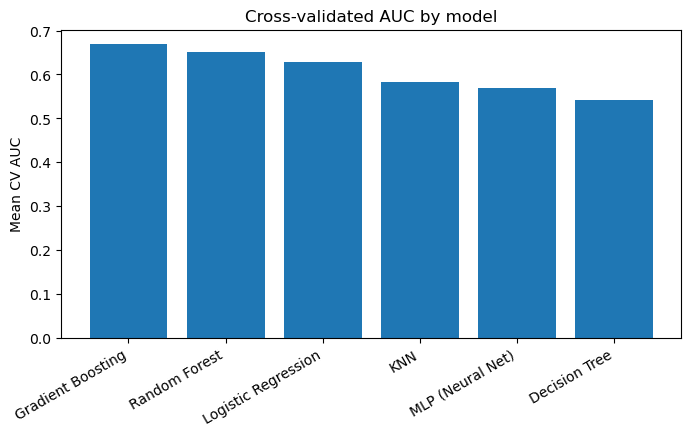

In [20]:
plt.figure(figsize=(8,4))
plt.bar(cv_results["model"], cv_results["cv_auc_mean"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean CV AUC")
plt.title("Cross-validated AUC by model")
plt.show()

## 10. Fit on the training split and evaluate on the holdout test split

In [21]:
holdout_rows = []
fitted_pipelines = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    holdout_rows.append({
        "model": name,
        "test_auc": roc_auc_score(y_test, y_prob),
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred, zero_division=0),
        "test_recall": recall_score(y_test, y_pred, zero_division=0),
        "test_f1": f1_score(y_test, y_pred, zero_division=0)
    })

holdout_results = pd.DataFrame(holdout_rows).sort_values("test_auc", ascending=False)
holdout_results

,model,test_auc,test_accuracy,test_precision,test_recall,test_f1
4,Gradient Boosting,0.678041,0.635059,0.178371,0.629679,0.277994
3,Random Forest,0.664649,0.889358,0.592233,0.026860,0.051390
0,Logistic Regression,0.643375,0.636632,0.165076,0.556143,0.254586
1,KNN,0.604021,0.586076,0.143866,0.547336,0.227843
5,MLP (Neural Net),0.581494,0.817530,0.164262,0.155438,0.159729
2,Decision Tree,0.547600,0.794782,0.176730,0.229414,0.199655


In [22]:
best_model_name = holdout_results.iloc[0]["model"]
best_pipe = fitted_pipelines[best_model_name]
print("Best baseline model on holdout AUC:", best_model_name)

Best baseline model on holdout AUC: Gradient Boosting


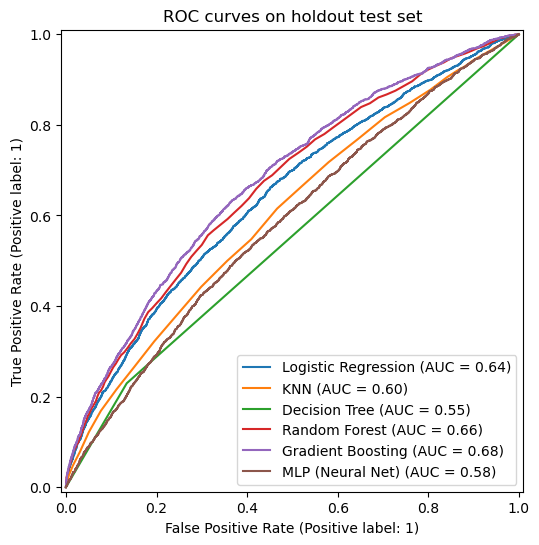

In [23]:
# ROC curves
plt.figure(figsize=(7,6))
for name, pipe in fitted_pipelines.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=plt.gca())
plt.title("ROC curves on holdout test set")
plt.show()

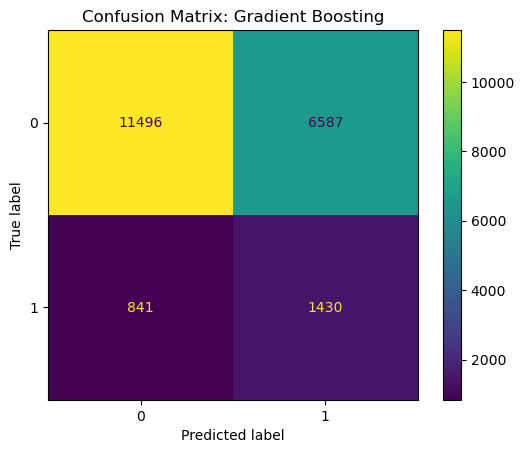

In [24]:
# Confusion matrix for the best baseline model
best_prob = best_pipe.predict_proba(X_test)[:, 1]
best_pred = (best_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

## 11. Hyperparameter tuning

We tune **Random Forest** using `RandomizedSearchCV` and compare tuned vs. untuned performance.

The tuned pipeline keeps the same preprocessing + **imblearn oversampling** steps, so balancing is still performed safely inside each CV split.

In [25]:
rf_pipe = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("sampler", RandomOverSampler(random_state=RANDOM_STATE)),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_dist = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [8, 16, None],
    "model__min_samples_split": [2, 10],
    "model__min_samples_leaf": [1, 4],
    "model__max_features": ["sqrt", None],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_dist,
    n_iter=5,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
print("Best params:", rf_search.best_params_)
print("Best CV AUC:", rf_search.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 16}
Best CV AUC: 0.650387555367107


In [26]:
tuned_rf = rf_search.best_estimator_

# Untuned RF
untuned_rf = pipelines["Random Forest"]
untuned_rf.fit(X_train, y_train)

untuned_prob = untuned_rf.predict_proba(X_test)[:, 1]
tuned_prob = tuned_rf.predict_proba(X_test)[:, 1]

comparison_df = pd.DataFrame({
    "version": ["Untuned Random Forest", "Tuned Random Forest"],
    "test_auc": [
        roc_auc_score(y_test, untuned_prob),
        roc_auc_score(y_test, tuned_prob)
    ]
})
comparison_df

,version,test_auc
0,Untuned Random Forest,0.664649
1,Tuned Random Forest,0.672191


## 12. Feature importance / interpretation

We use the tuned Random Forest if available.  
Because the pipeline includes one-hot encoding, we extract transformed feature names first.

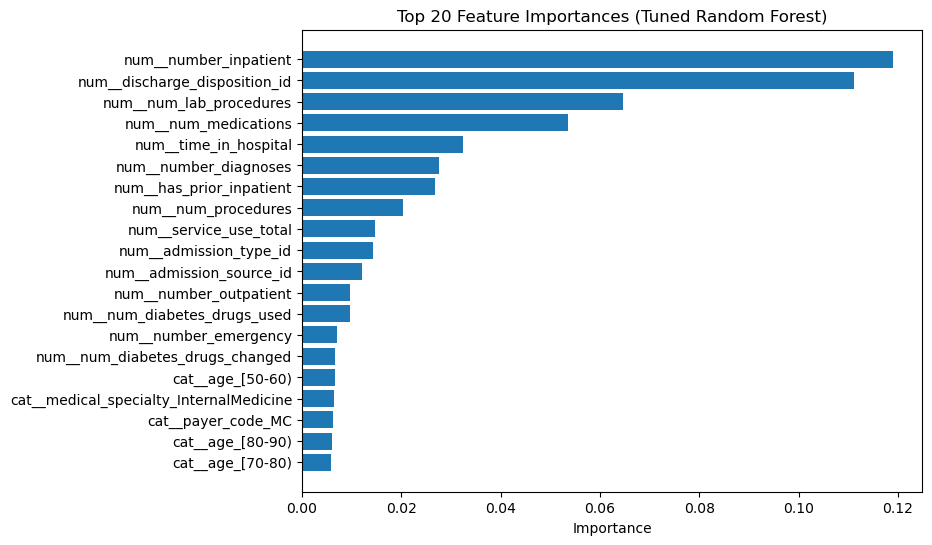

,importance
num__number_inpatient,0.118900
num__discharge_disposition_id,0.111040
num__num_lab_procedures,0.064577
num__num_medications,0.053533
num__time_in_hospital,0.032394
num__number_diagnoses,0.027572
num__has_prior_inpatient,0.026679
num__num_procedures,0.020264
num__service_use_total,0.014642
num__admission_type_id,0.014328


In [27]:
final_model = tuned_rf

# Get transformed feature names
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

# For tree-based models with feature_importances_
rf_model = final_model.named_steps["model"]
importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

top_k = 20
top_importances = importances.head(top_k)

plt.figure(figsize=(8,6))
plt.barh(top_importances.index[::-1], top_importances.values[::-1])
plt.title(f"Top {top_k} Feature Importances (Tuned Random Forest)")
plt.xlabel("Importance")
plt.show()

top_importances.to_frame("importance")

## 13. Optional: permutation importance

This is slower, but often easier to explain in the report.

In [28]:
# Uncomment if you want permutation importance (can be slow)
# perm = permutation_importance(
#     final_model, X_test, y_test,
#     n_repeats=5,
#     random_state=42,
#     scoring="roc_auc",
#     n_jobs=-1
# )
# perm_importances = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
# perm_importances.head(20)

## 14. Summary for the report

Use this section to write your final discussion.

### Suggested interpretation points
- Which model achieved the best AUC?
- Did tree-based ensembles outperform simpler baselines?
- Did tuning Random Forest improve holdout AUC?
- Which features were most predictive?
- Are the most important features clinically plausible?

### Suggested real-world discussion
- Hospitals could use this model to flag higher-risk diabetic patients before discharge.
- This may support follow-up planning, care management, and readmission reduction.
- However, the dataset is old (1999–2008), and healthcare practice may have changed.
- Some variables may encode structural bias (e.g., race, payer status, admission source).
- The model should assist decision-making, not replace clinician judgment.

## 15. Export results tables (optional)

In [29]:
# Save model comparison results if desired
cv_results.to_csv("cv_model_comparison.csv", index=False)
holdout_results.to_csv("holdout_model_comparison.csv", index=False)
comparison_df.to_csv("tuned_vs_untuned_random_forest.csv", index=False)

print("Saved:")
print("- cv_model_comparison.csv")
print("- holdout_model_comparison.csv")
print("- tuned_vs_untuned_random_forest.csv")

Saved:
- cv_model_comparison.csv
- holdout_model_comparison.csv
- tuned_vs_untuned_random_forest.csv


## 16. Next steps you can add if you want a stronger project

- Compare raw features vs. engineered features
- Replace `RandomOverSampler` with `SMOTE` and compare results
- Add threshold tuning based on precision-recall tradeoffs
- Replace Gradient Boosting with XGBoost / LightGBM if allowed
- Add calibration plots
- Add subgroup performance checks by age / race / gender for fairness analysis
- Merge the ID mapping file to make categorical codes more interpretable in plots